In [21]:
import numpy as np
import gymnasium as gym
from gymnasium.spaces import Box, Discrete
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical, Normal
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
import random
import collections
from pettingzoo.mpe import simple_tag_v3
import pickle
import time

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [22]:
class MultiAgentWarehouseEnv:
    GRID_SIZE = 10
    NUM_AGENTS = 4
    DELIVERY_QUOTA = 4  
    
    REWARD_STEP = -0.5
    REWARD_PICKUP = 50
    REWARD_DROPOFF = 150
    PENALTY_WALL_HIT = -10
    PENALTY_AGENT_COLLISION = -10
    
    CELL_EMPTY = 0
    CELL_WALL = 1
    CELL_AGENT = 2

    ACTION_UP = "up"
    ACTION_DOWN = "down"
    ACTION_LEFT = "left"
    ACTION_RIGHT = "right"
    ACTION_PICKUP = "pick_up"
    ACTION_DROPOFF = "drop_off"
    ACTION_WAIT = "wait"

    def __init__(self):
        self.action_space = [
            self.ACTION_UP, 
            self.ACTION_DOWN, 
            self.ACTION_LEFT, 
            self.ACTION_RIGHT, 
            self.ACTION_PICKUP, 
            self.ACTION_DROPOFF,
            self.ACTION_WAIT
        ]
        
        self.pickup_locations = [
            (1, 1), 
            (1, self.GRID_SIZE - 2), 
            (self.GRID_SIZE - 2, 1), 
            (self.GRID_SIZE - 2, self.GRID_SIZE - 2)
        ]
        
        self.dropoff_location = (self.GRID_SIZE // 2, self.GRID_SIZE // 2)

        self.shelves = [
            (3, 3), (3, 6), (6, 3), (6, 6), 
            (4, 2), (5, 2), (4, 7), (5, 7)
        ]

        self.figure = None
        self.axis = None

        self.reset()

    def reset(self):
        self.agents = [] 
        self.total_rewards = [0] * self.NUM_AGENTS
        self.items_delivered = 0 
        self.pickup_availability = [True, True, True, True]

        while len(self.agents) < self.NUM_AGENTS:
            row = random.randint(0, self.GRID_SIZE - 1)
            col = random.randint(0, self.GRID_SIZE - 1)
            position = (row, col)
            
            is_valid = True
            
            if position in self.shelves:
                is_valid = False
            
            if position in self.pickup_locations:
                is_valid = False
                
            if position == self.dropoff_location:
                is_valid = False
            
            for agent in self.agents:
                agent_pos = tuple(agent[0])

                if agent_pos == position:
                    is_valid = False
                    break
            
            if is_valid:
                self.agents.append([list(position), False])
        
        return self.get_observations()

    def get_observations(self):
        observations = []
        
        for agent_index in range(self.NUM_AGENTS):
            current_pos = self.agents[agent_index][0]
            has_item = self.agents[agent_index][1]

            sensor_readings = self.get_sensor_readings(current_pos, agent_index)
            
            state = (
                current_pos[0], 
                current_pos[1], 
                int(has_item), 
                sensor_readings[0], 
                sensor_readings[1], 
                sensor_readings[2], 
                sensor_readings[3]
            )
            observations.append(state)
            
        return observations

    def get_sensor_readings(self, position, current_agent_index):
        row, col = position
        
        directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        readings = []
        
        for direction in directions:
            delta_row = direction[0]
            delta_col = direction[1]
            
            check_row = row + delta_row
            check_col = col + delta_col
            
            reading = self.CELL_EMPTY
            
            is_off_grid = False

            if check_row < 0:
                is_off_grid = True
            
            if check_row >= self.GRID_SIZE:
                is_off_grid = True
            
            if check_col < 0:
                is_off_grid = True
            
            if check_col >= self.GRID_SIZE:
                is_off_grid = True
            
            if is_off_grid:
                reading = self.CELL_WALL
            
            elif (check_row, check_col) in self.shelves:
                reading = self.CELL_WALL
            
            else:
                for other_index in range(self.NUM_AGENTS):
                    if current_agent_index == other_index:
                        continue
                    
                    other_agent_pos = self.agents[other_index][0]
                    if other_agent_pos[0] == check_row:
                        if other_agent_pos[1] == check_col:
                            reading = self.CELL_AGENT
                            break
            
            readings.append(reading)
            
        return tuple(readings)

    def step(self, actions):
        rewards = [self.REWARD_STEP] * self.NUM_AGENTS
        dones = [False] * self.NUM_AGENTS
        intended_positions = []

        for agent_index in range(self.NUM_AGENTS):
            action = actions[agent_index]
            row = self.agents[agent_index][0][0]
            col = self.agents[agent_index][0][1]
            has_item = self.agents[agent_index][1]

            old_pos = (row, col)

            random_val = random.random()
            
            if random_val < 0.2: 
                intended_positions.append((row, col))
                continue

            new_row, new_col = row, col
            
            if action == self.ACTION_UP and row > 0: new_row -= 1
            elif action == self.ACTION_DOWN and row < self.GRID_SIZE - 1: new_row += 1
            elif action == self.ACTION_LEFT and col > 0: new_col -= 1
            elif action == self.ACTION_RIGHT and col < self.GRID_SIZE - 1: new_col += 1
            
            elif action == self.ACTION_PICKUP:
                if not has_item:
                    if (row, col) in self.pickup_locations:
                        location_index = self.pickup_locations.index((row, col))
                        if self.pickup_availability[location_index]:
                            self.agents[agent_index][1] = True
                            self.pickup_availability[location_index] = False
                            rewards[agent_index] += self.REWARD_PICKUP
            
            elif action == self.ACTION_DROPOFF:
                if has_item and ((row, col) == self.dropoff_location):
                    self.agents[agent_index][1] = False
                    rewards[agent_index] += self.REWARD_DROPOFF
                    self.items_delivered += 1

            intended_positions.append((new_row, new_col))

        final_positions = []

        for agent_index in range(self.NUM_AGENTS):
            intended_pos = intended_positions[agent_index]
            if intended_pos in self.shelves:
                rewards[agent_index] += self.PENALTY_WALL_HIT
                final_positions.append(tuple(self.agents[agent_index][0])) 
            else:
                final_positions.append(intended_pos)

        target_counts = collections.Counter(final_positions)
        realized_positions = []
        
        for agent_index in range(self.NUM_AGENTS):
            target_pos = final_positions[agent_index]
            if target_counts[target_pos] > 1:
                rewards[agent_index] += self.PENALTY_AGENT_COLLISION
                realized_positions.append(tuple(self.agents[agent_index][0])) 
            else:
                realized_positions.append(target_pos)

        for agent_index in range(self.NUM_AGENTS):
            new_pos_tuple = realized_positions[agent_index]
            old_pos = self.agents[agent_index][0]
            has_item = self.agents[agent_index][1]
            
            target = None
            if has_item:
                target = self.dropoff_location
            else:
                best_dist = float("inf")
                for i, loc in enumerate(self.pickup_locations):
                    if self.pickup_availability[i]:
                        d = abs(loc[0] - old_pos[0]) + abs(loc[1] - old_pos[1])
                        if d < best_dist:
                            best_dist = d
                            target = loc
            
            if target:
                old_dist = abs(target[0] - old_pos[0]) + abs(target[1] - old_pos[1])
                new_dist = abs(target[0] - new_pos_tuple[0]) + abs(target[1] - new_pos_tuple[1])
                
                if new_dist < old_dist:
                    rewards[agent_index] += 0.2 
                elif new_dist > old_dist:
                    rewards[agent_index] -= 0.1 

            self.agents[agent_index][0] = [new_pos_tuple[0], new_pos_tuple[1]]
            self.total_rewards[agent_index] += rewards[agent_index]
            
        if self.items_delivered >= self.DELIVERY_QUOTA:
            dones = [True] * self.NUM_AGENTS

        return self.get_observations(), rewards, dones, {}
    

    def render(self):
        fig, ax = plt.subplots(figsize=(7.5, 6))
        
        hub_row, hub_col = self.dropoff_location
        inverted_hub_row = self.GRID_SIZE - 1 - hub_row
      
        ax.add_patch(patches.Rectangle((hub_col, inverted_hub_row), 1, 1, color="blue", alpha=0.5))
        ax.text(hub_col + 0.5, inverted_hub_row + 0.5, "HUB", color="white", ha="center", va="center", weight="bold")

        for shelf_row, shelf_col in self.shelves:
            inverted_row = self.GRID_SIZE - 1 - shelf_row
            ax.add_patch(patches.Rectangle((shelf_col, inverted_row), 1, 1, color="grey"))

        for index in range(len(self.pickup_locations)):
            if self.pickup_availability[index] == True:
                pickup_row, pickup_col = self.pickup_locations[index]
                inverted_row = self.GRID_SIZE - 1 - pickup_row
                
                ax.add_patch(patches.Rectangle((pickup_col, inverted_row), 1, 1, color="green", alpha=0.5))
                ax.text(pickup_col + 0.5, inverted_row + 0.5, "P", color="white", ha="center", va="center", weight="bold")

        for agent_index in range(self.NUM_AGENTS):
            agent_data = self.agents[agent_index]
            agent_row = agent_data[0][0]
            agent_col = agent_data[0][1]
            has_item = agent_data[1]
            
            if has_item:
                agent_color = "gold"
            else: 
                agent_color = "red"

            text_color = "white"

            inverted_row = self.GRID_SIZE - 1 - agent_row
            
            ax.add_patch(patches.Circle((agent_col + 0.5, inverted_row + 0.5), 0.35, color=agent_color))
            ax.text(agent_col + 0.5, inverted_row + 0.5, str(agent_index), 
                            color=text_color, ha="center", va="center", weight="bold")


        legend_handles = [
            patches.Patch(color="red", label="Agent (Empty)"),
            patches.Patch(color="gold", label="Agent (Carrying Item)"),
            patches.Patch(color="green", alpha=0.5, label="Pickup Spot (Available)"),
            patches.Patch(color="blue", alpha=0.5, label="Dropoff HUB"),
            patches.Patch(color="grey", label="Shelf / Wall")
        ]
        
        ax.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(1.35, 1.0), fontsize=9)

        ax.set_xlim(0, 10)
        ax.set_ylim(0, 10)
        ax.set_xticks(np.arange(0, 11, 1))
        ax.set_yticks(np.arange(0, 11, 1))
        ax.grid(True, color="gray", linestyle="--", linewidth=0.5)
        ax.set_title(f"Delivered: {self.items_delivered}/{self.DELIVERY_QUOTA}")
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        
        plt.show() 
        plt.close(fig)

In [23]:

env = MultiAgentWarehouseEnv()
actions = env.action_space

Q_tables = [{} for _ in range(env.NUM_AGENTS)]

def get_q(agent_index, state, action):
    key = (state, action)

    if key not in Q_tables[agent_index]:
        Q_tables[agent_index][key] = 0.0

    return Q_tables[agent_index][key]

def set_q(agent_index, state, action, value):
    key = (state, action)
    Q_tables[agent_index][key] = value

def choose_action(agent_index, state, epsilon):
    if random.random() < epsilon:
        return random.choice(actions)
    
    values = [get_q(agent_index, state, action) for action in actions]
    max_val = max(values)
    
    best_actions = [actions[index] for index in range(len(actions)) if values[index] == max_val]
    return random.choice(best_actions)

def update_Q(agent_index, state, action, reward, next_state, alpha, gamma):
    current_q = get_q(agent_index, state, action) 
    
    next_vals = [get_q(agent_index, next_state, action) for action in actions]
    max_next_q = max(next_vals)
    target_q = reward + (gamma * max_next_q)
    
    new_q = current_q + (alpha * (target_q - current_q))
    
    set_q(agent_index, state, action, new_q)

In [24]:
alpha = 0.1
gamma = 0.99 
epsilon = 1.0
epsilon_decay = 0.999 
epsilon_min = 0.05
max_steps = 200
episodes = 5000

rewards_per_episode = []
epsilon_over_episodes = []

print("Starting Warehouse Independent Q-Learning Training...")

for episode in range(episodes):
    observations = env.reset()
    
    total_episode_reward = 0
    done = False
    
    for step in range(max_steps):
        action_list = []
        for agent_index in range(env.NUM_AGENTS):
            action = choose_action(agent_index, observations[agent_index], epsilon)
            action_list.append(action)
            
        next_observations, rewards, dones, _ = env.step(action_list)
        
        for agent_index in range(env.NUM_AGENTS):
            update_Q(agent_index, 
                     observations[agent_index], 
                     action_list[agent_index], 
                     rewards[agent_index], 
                     next_observations[agent_index], 
                     alpha, 
                     gamma)
            
        observations = next_observations
        total_episode_reward += sum(rewards)
        
        if all(dones):
            done = True
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    epsilon_over_episodes.append(epsilon)
    rewards_per_episode.append(total_episode_reward)

    if (episode + 1) % 100 == 0:
        print(f"Episode: {episode + 1}, Total Reward: {total_episode_reward:.2f}, Epsilon: {epsilon:.3f}, Delivered: {env.items_delivered}")

print(f"\nTraining Complete.")

with open("multi_agent_q_tables.pkl", "wb") as file:
    pickle.dump(Q_tables, file)



Starting Warehouse Independent Q-Learning Training...
Episode: 100, Total Reward: -703.70, Epsilon: 0.905, Delivered: 0
Episode: 200, Total Reward: -52.00, Epsilon: 0.819, Delivered: 3
Episode: 300, Total Reward: -8.00, Epsilon: 0.741, Delivered: 3
Episode: 400, Total Reward: 417.00, Epsilon: 0.670, Delivered: 4
Episode: 500, Total Reward: -88.80, Epsilon: 0.606, Delivered: 4
Episode: 600, Total Reward: 606.20, Epsilon: 0.549, Delivered: 4
Episode: 700, Total Reward: 580.10, Epsilon: 0.496, Delivered: 4
Episode: 800, Total Reward: 453.10, Epsilon: 0.449, Delivered: 4
Episode: 900, Total Reward: 460.30, Epsilon: 0.406, Delivered: 4
Episode: 1000, Total Reward: -229.20, Epsilon: 0.368, Delivered: 3
Episode: 1100, Total Reward: 673.00, Epsilon: 0.333, Delivered: 4
Episode: 1200, Total Reward: 517.70, Epsilon: 0.301, Delivered: 4
Episode: 1300, Total Reward: -117.60, Epsilon: 0.272, Delivered: 3
Episode: 1400, Total Reward: 592.70, Epsilon: 0.246, Delivered: 4
Episode: 1500, Total Reward: 

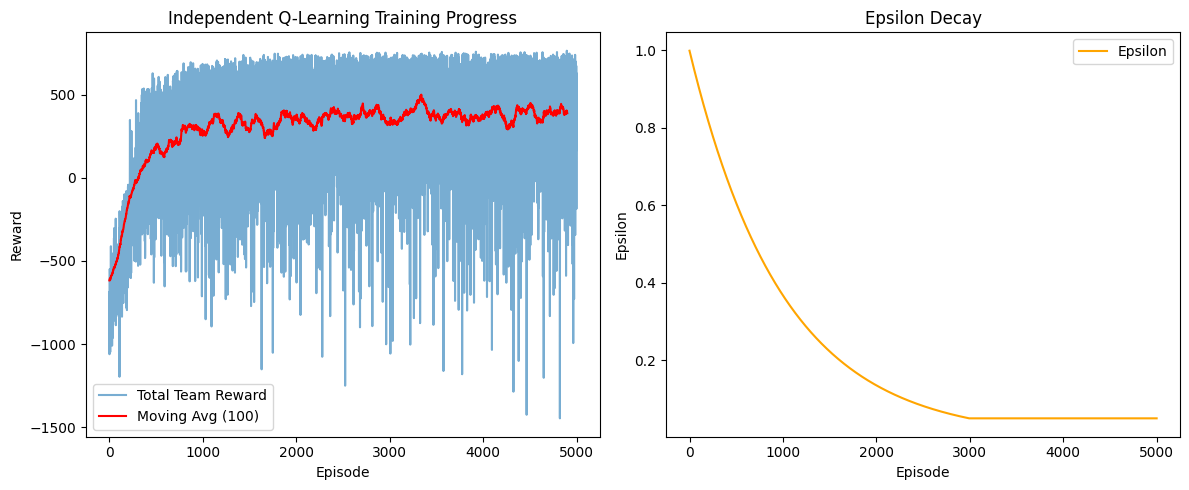

In [25]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(episodes), rewards_per_episode, label="Total Team Reward", alpha=0.6)

moving_avg = np.convolve(rewards_per_episode, np.ones(100) / 100, mode="valid")
plt.plot(range(len(moving_avg)), moving_avg, label="Moving Avg (100)", color="red")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Independent Q-Learning Training Progress")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(episodes), epsilon_over_episodes, label="Epsilon", color="orange")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("Epsilon Decay")
plt.legend()

plt.tight_layout()
plt.show()




Running Final Greedy Evaluation with Visualization...


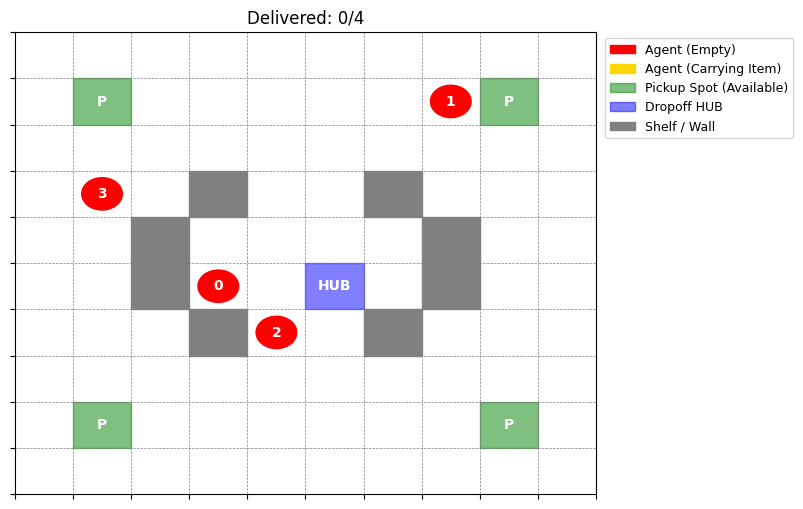

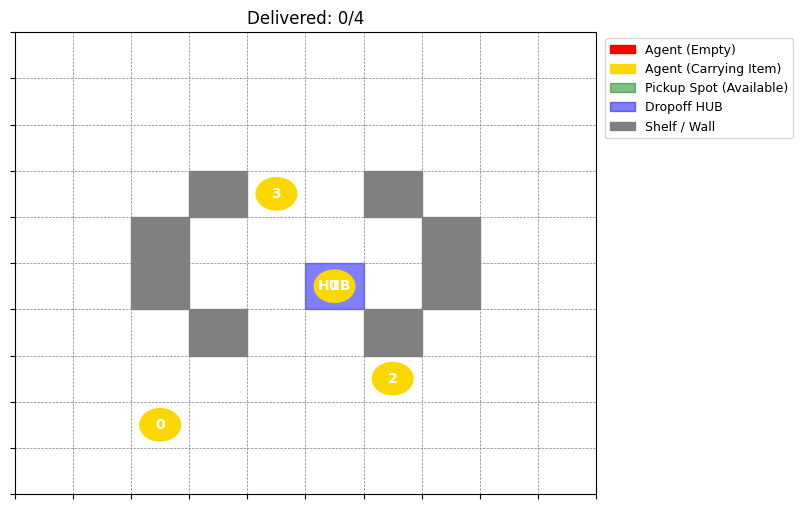

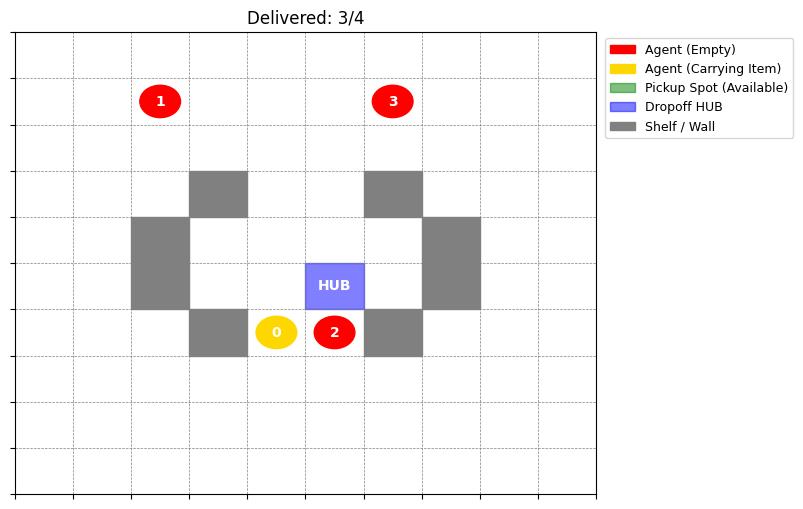

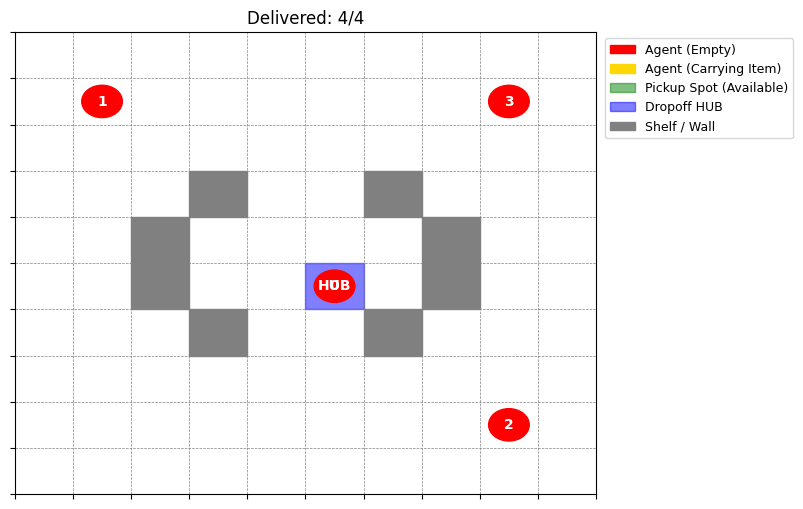

Success! All items delivered in 24 steps.
Evaluation Finished. Total Reward: 738.30


In [39]:
def get_greedy_action(agent_index, state, action_space):
    values = [get_q(agent_index, state, action) for action in action_space]
    max_val = max(values)
    best_actions = [action_space[action_index] for action_index in range(len(action_space)) if values[action_index] == max_val]
    return random.choice(best_actions)

print("\nRunning Final Greedy Evaluation with Visualization...")

observations = env.reset()
done = False
current_step = 0
total_reward_q = 0
counter = 0

try:
    while not done and current_step < max_steps:

        if counter % 10 == 0:
            env.render()
        
        counter += 1
        
        action_list = []
        for agent_index in range(env.NUM_AGENTS):
            action = get_greedy_action(agent_index, observations[agent_index], env.action_space)
            action_list.append(action)
            
        next_observations, rewards, dones, _ = env.step(action_list)

        total_reward_q += sum(rewards)

        observations = next_observations
        
        if all(dones):
            env.render()
            print(f"Success! All items delivered in {current_step} steps.")
            done = True
            
        current_step += 1
        time.sleep(0.2)
        
except KeyboardInterrupt:
    print("Visualization stopped by user.")

print(f"Evaluation Finished. Total Reward: {total_reward_q:.2f}")

In [27]:
class QNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
        
    def forward(self, x):
        return self.net(x)

class ExperienceReplayBuffer:
    def __init__(self, capacity):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)
    
    def buffer_size(self):
        return len(self.buffer)

In [28]:
class DDQNAgent:
    def __init__(self, input_dim, output_dim):
        self.policy_net = QNetwork(input_dim, output_dim).to(device)
        self.target_net = QNetwork(input_dim, output_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=0.0005)
        self.loss_fn = nn.MSELoss()
        self.buffer = ExperienceReplayBuffer(capacity=50000)
        self.action_space_size = output_dim

    def get_action(self, state, epsilon):
        if random.random() < epsilon:
            return random.randint(0, self.action_space_size - 1)
        
        state_tensor = torch.FloatTensor(np.array(state)).unsqueeze(0).to(device)
        
        with torch.no_grad():
            q_values = self.policy_net(state_tensor)
            
        return q_values.argmax().item()

    def train_step(self, batch_size, gamma):
        if self.buffer.buffer_size() < batch_size: return
        
        transitions = self.buffer.sample(batch_size)
        states, actions, rewards, next_states, dones = zip(*transitions)

        states = torch.FloatTensor(np.array(states)).to(device)
        actions = torch.LongTensor(np.array(actions)).unsqueeze(-1).to(device)
        rewards = torch.FloatTensor(np.array(rewards)).to(device)
        next_states = torch.FloatTensor(np.array(next_states)).to(device)
        dones = torch.FloatTensor(np.array(dones)).to(device)
        current_q = self.policy_net(states).gather(1, actions).squeeze()

        with torch.no_grad():
            next_actions = self.policy_net(next_states).argmax(dim=1).unsqueeze(-1)
            next_q_target = self.target_net(next_states).gather(1, next_actions).squeeze()
        
        target_q = rewards + (gamma * next_q_target * (1 - dones))

        self.optimizer.zero_grad()
        loss = self.loss_fn(current_q, target_q)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()
        
    def update_target_net(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

In [29]:
def normalize_state(state):
    row, col, has_item = state[0], state[1], state[2]
    sensors = state[3:]
    
    norm_row = row / env.GRID_SIZE
    norm_col = col / env.GRID_SIZE
    
    sensor_encoding = []

    for s in sensors:
        encoding = [0, 0, 0]
        encoding[int(s)] = 1
        sensor_encoding.extend(encoding)
        
    return np.array([norm_row, norm_col, has_item] + sensor_encoding, dtype=np.float32)

INPUT_DIM = 15
OUTPUT_DIM = 7
BATCH_SIZE = 64
TARGET_UPDATE_FREQ = 100
EPISODES = 5000
MAX_STEPS = 200
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_DECAY = 0.9995
EPSILON_MIN = 0.05

env = MultiAgentWarehouseEnv()
warehouse_agent = DDQNAgent(input_dim=INPUT_DIM, output_dim=OUTPUT_DIM)

rewards_per_episode = []
epsilon = EPSILON_START

print("Starting DDQN Warehouse Training...")

for episode in range(EPISODES):
    observations = env.reset()
    norm_observations = [normalize_state(obs) for obs in observations]
    total_episode_reward = 0
    
    if episode % TARGET_UPDATE_FREQ == 0:
        warehouse_agent.update_target_net()

    for step in range(MAX_STEPS):
        action_indices = []
        for i in range(env.NUM_AGENTS):
            action = warehouse_agent.get_action(norm_observations[i], epsilon)
            action_indices.append(action)
        
        action_strings = [env.action_space[index] for index in action_indices]
        next_observations, rewards, dones, _ = env.step(action_strings)
        scaled_rewards = [reward / 100.0 for reward in rewards]
        norm_next_observations = [normalize_state(obs) for obs in next_observations]
        global_done = all(dones)

        for i in range(env.NUM_AGENTS):
            warehouse_agent.buffer.push(
                norm_observations[i], action_indices[i], scaled_rewards[i], 
                norm_next_observations[i], global_done
            )
            warehouse_agent.train_step(batch_size=BATCH_SIZE, gamma=GAMMA)

        norm_observations = norm_next_observations
        total_episode_reward += sum(rewards)
        if global_done: 
            break
            
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)
    rewards_per_episode.append(total_episode_reward)

    if (episode + 1) % 100 == 0:
        print(f"Episode {episode + 1}, Reward: {total_episode_reward:.2f}, Epsilon: {epsilon:.3f}")

Starting DDQN Warehouse Training...
Episode 100, Reward: -780.10, Epsilon: 0.951
Episode 200, Reward: -411.50, Epsilon: 0.905
Episode 300, Reward: -744.40, Epsilon: 0.861
Episode 400, Reward: -535.20, Epsilon: 0.819
Episode 500, Reward: -743.50, Epsilon: 0.779
Episode 600, Reward: -344.60, Epsilon: 0.741
Episode 700, Reward: -466.30, Epsilon: 0.705
Episode 800, Reward: -51.90, Epsilon: 0.670
Episode 900, Reward: -182.40, Epsilon: 0.638
Episode 1000, Reward: 421.40, Epsilon: 0.606
Episode 1100, Reward: 409.60, Epsilon: 0.577
Episode 1200, Reward: -250.20, Epsilon: 0.549
Episode 1300, Reward: 221.60, Epsilon: 0.522
Episode 1400, Reward: -200.10, Epsilon: 0.496
Episode 1500, Reward: 377.80, Epsilon: 0.472
Episode 1600, Reward: -1329.80, Epsilon: 0.449
Episode 1700, Reward: 524.90, Epsilon: 0.427
Episode 1800, Reward: -542.00, Epsilon: 0.406
Episode 1900, Reward: -230.90, Epsilon: 0.387
Episode 2000, Reward: 602.40, Epsilon: 0.368
Episode 2100, Reward: 457.10, Epsilon: 0.350
Episode 2200, 

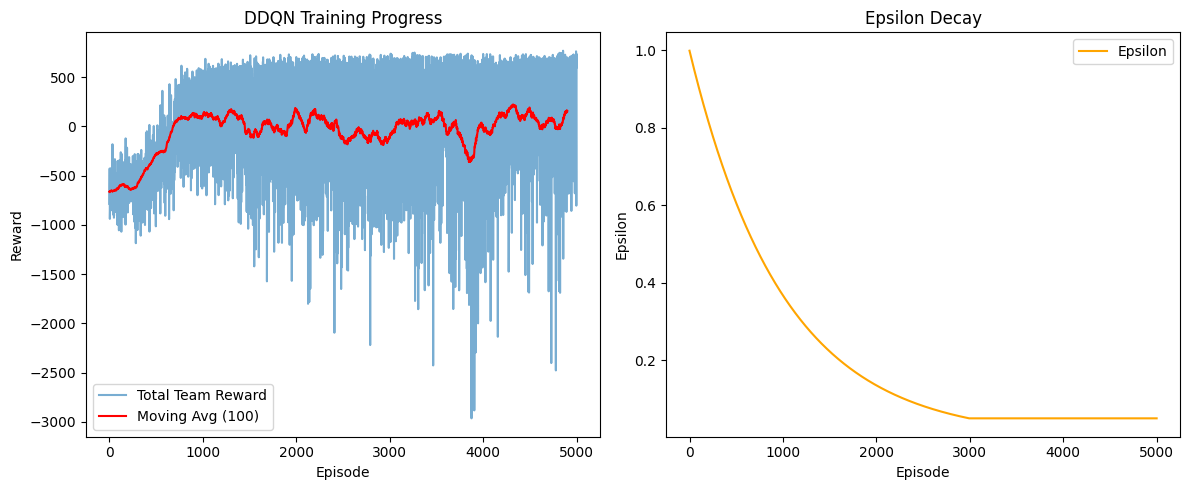

In [30]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(rewards_per_episode, label="Total Team Reward", alpha=0.6)
moving_avg = np.convolve(rewards_per_episode, np.ones(100) / 100, mode="valid")
plt.plot(moving_avg, label="Moving Avg (100)", color="red")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DDQN Training Progress")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epsilon_over_episodes, label="Epsilon", color="orange")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("Epsilon Decay")
plt.legend()

plt.tight_layout()
plt.show()

Running DDQN Evaluation...


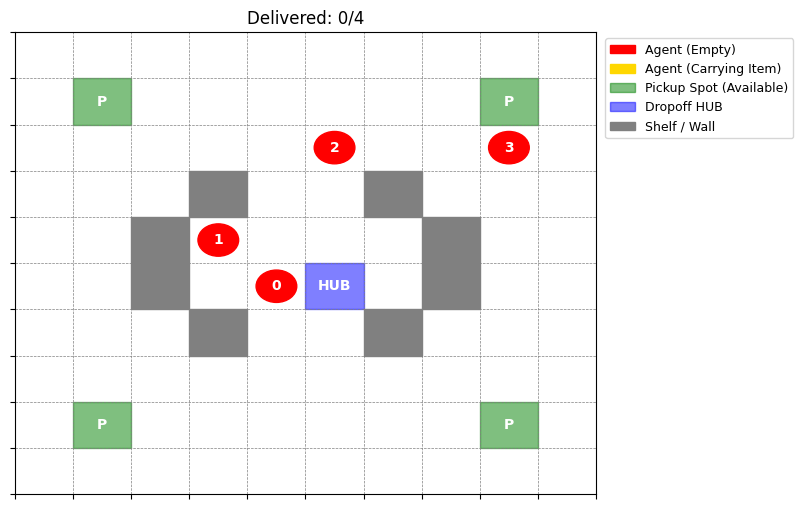

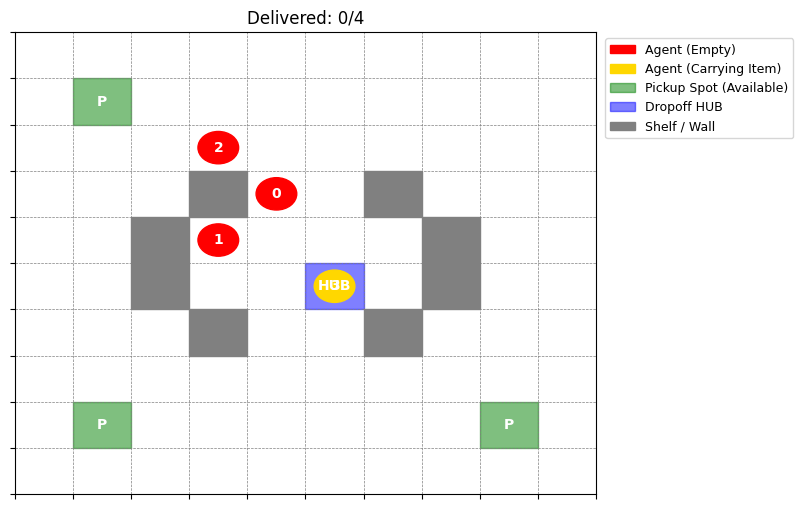

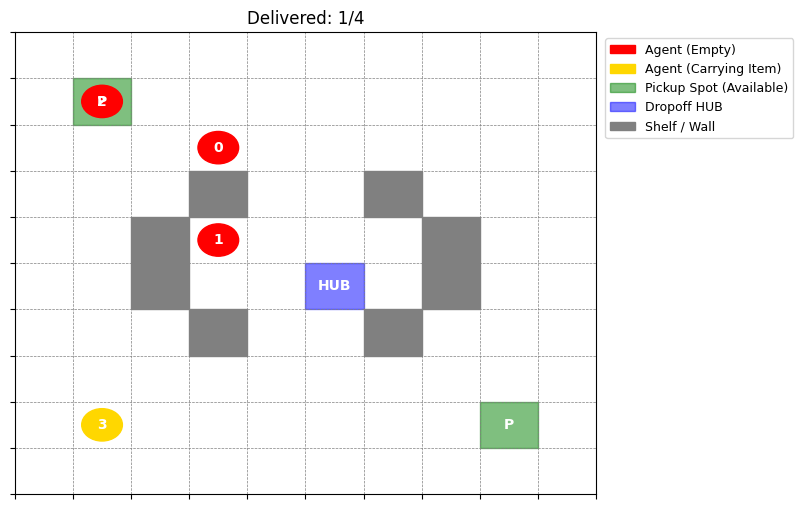

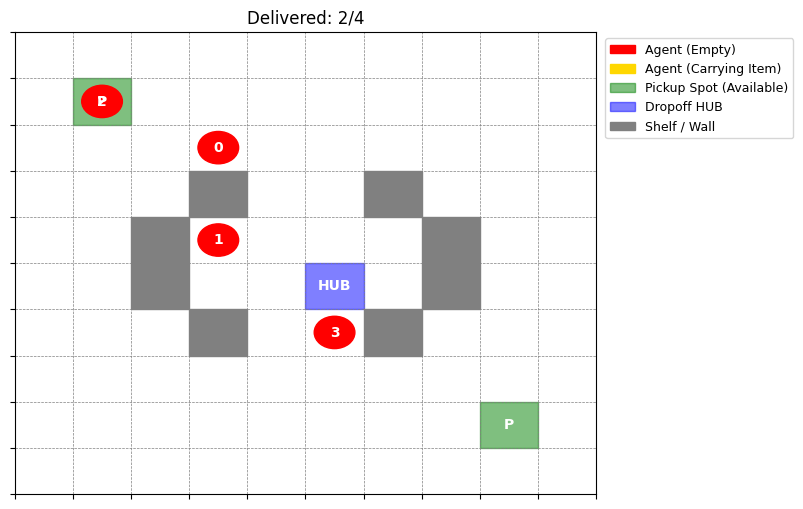

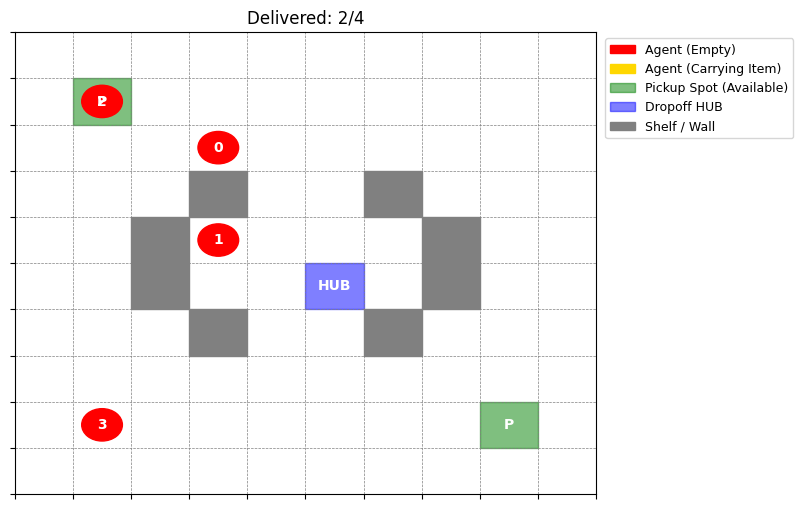

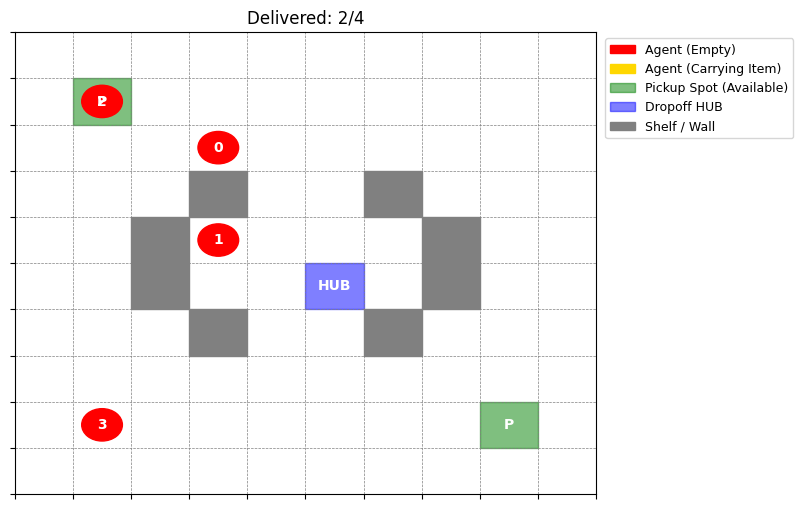

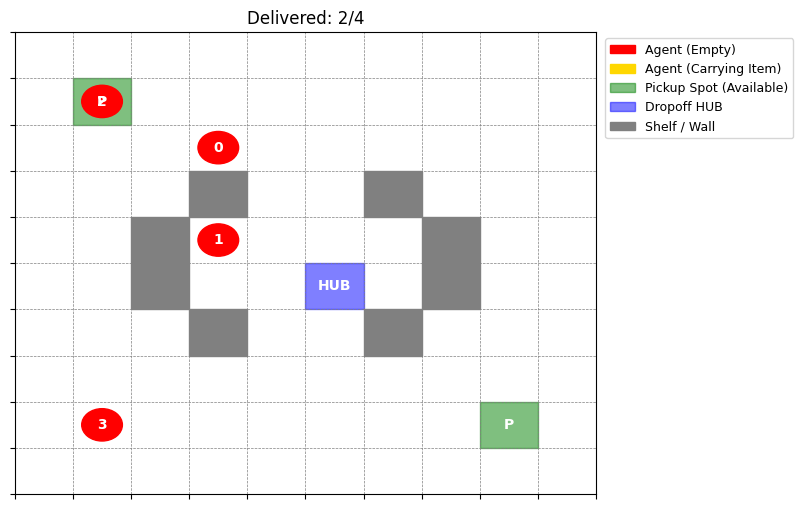

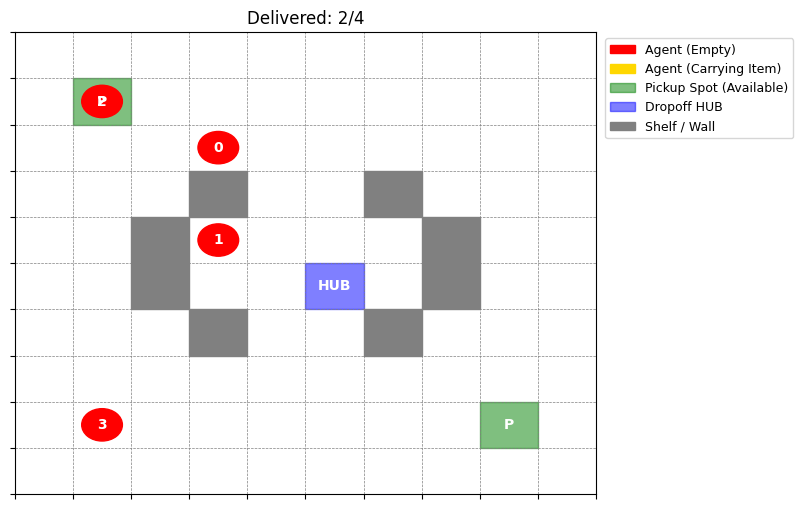

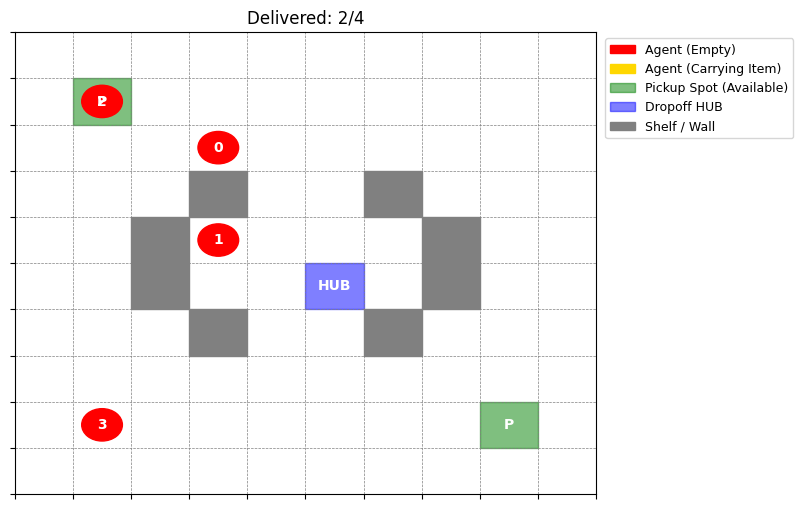

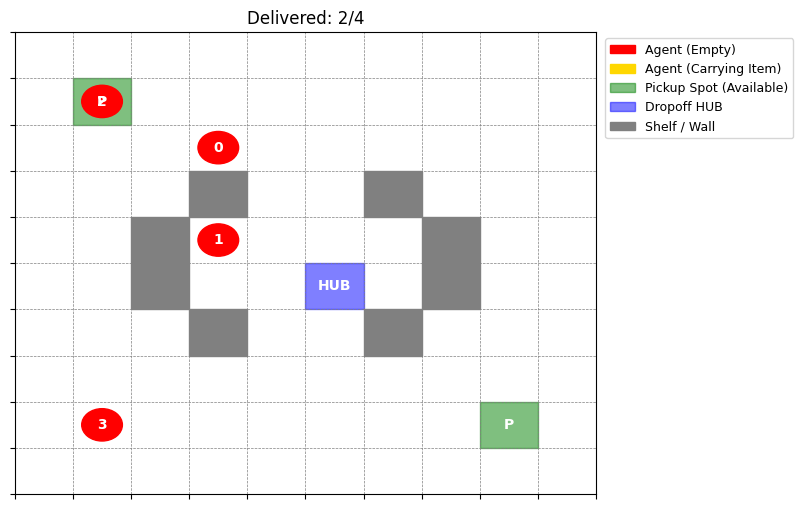

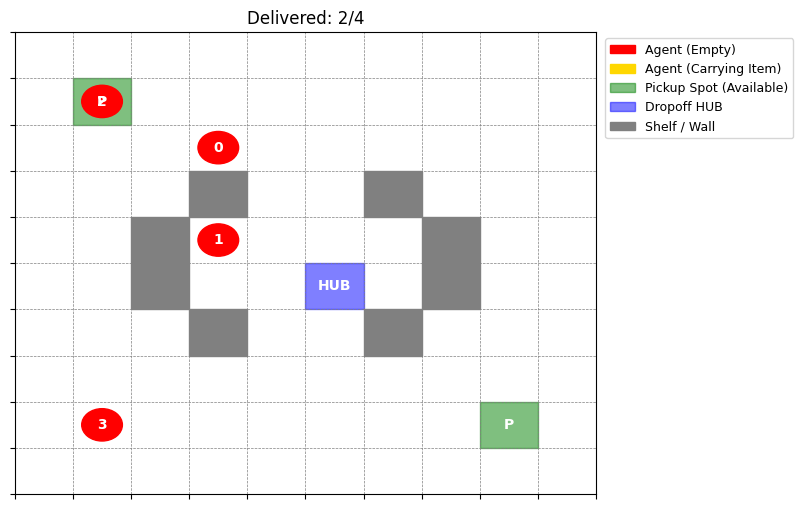

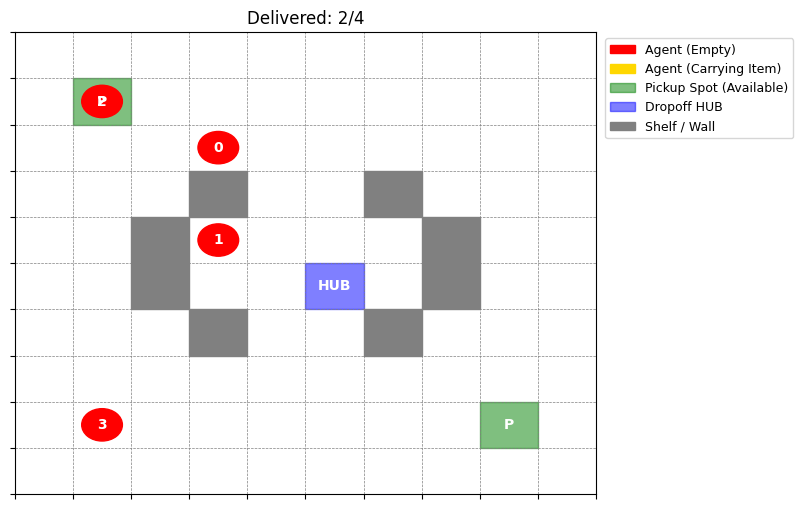

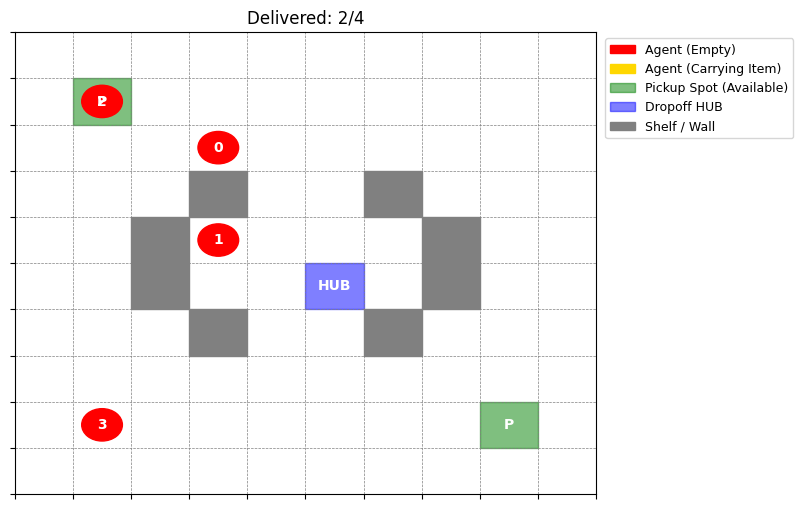

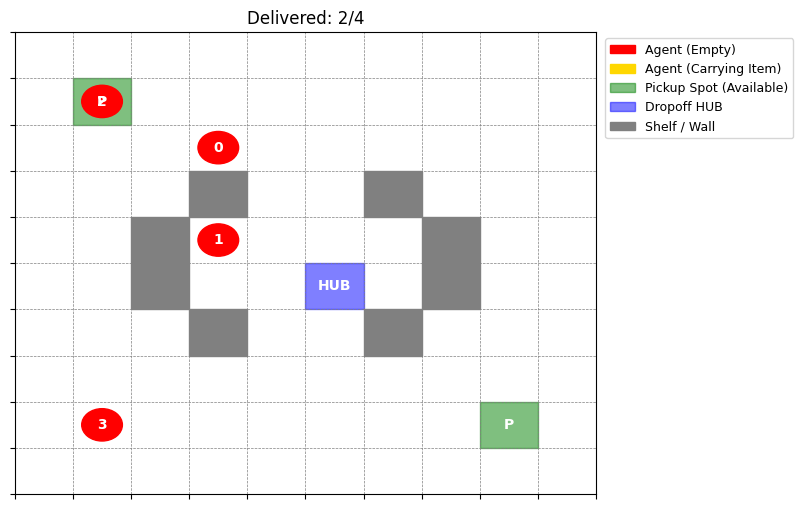

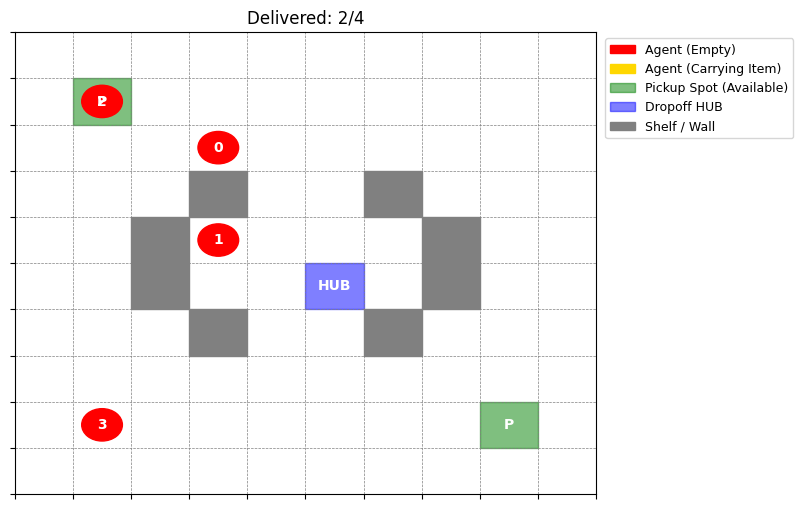

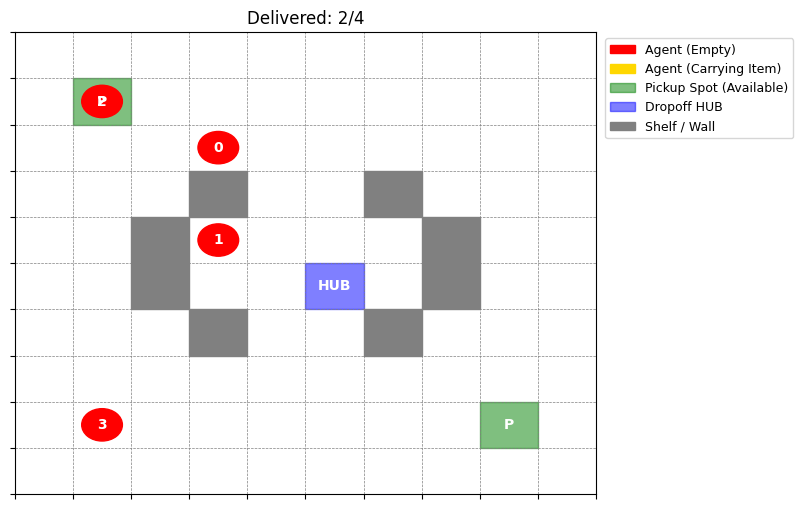

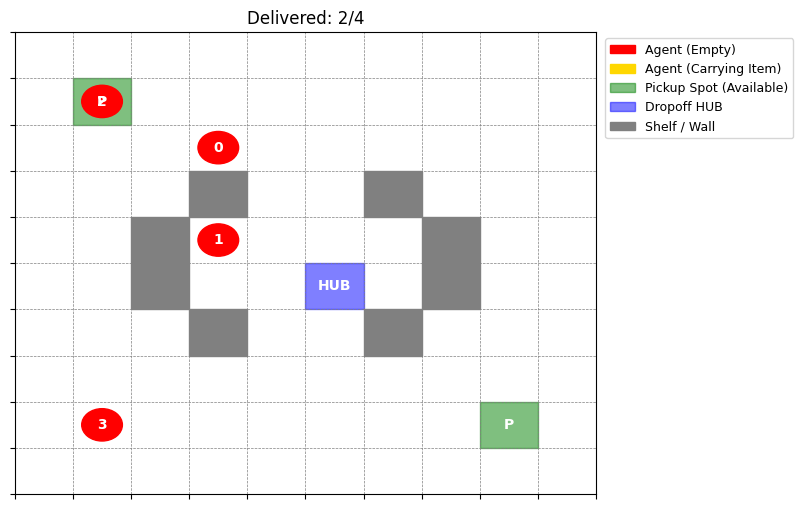

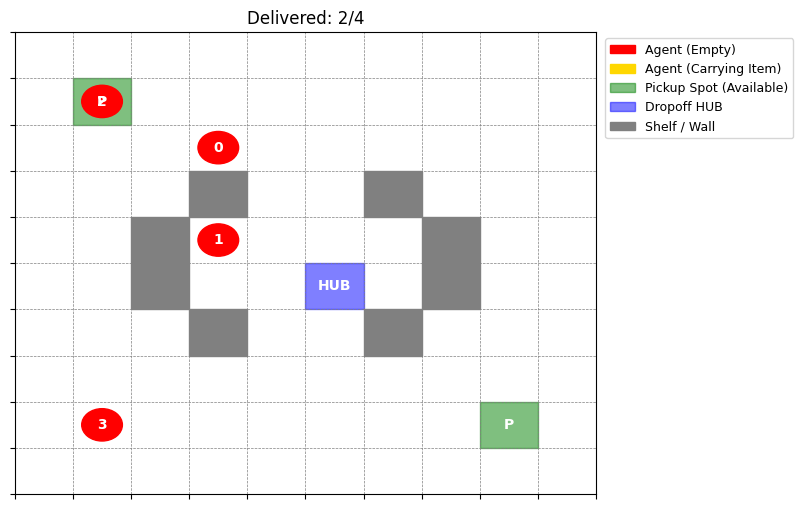

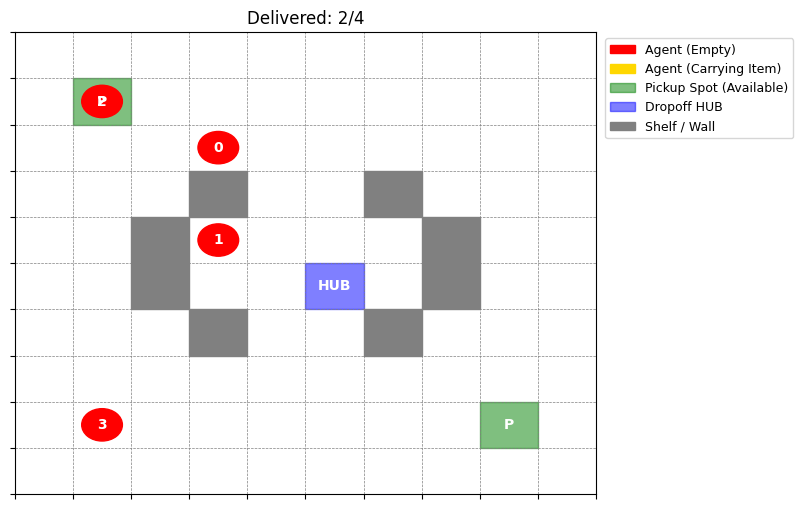

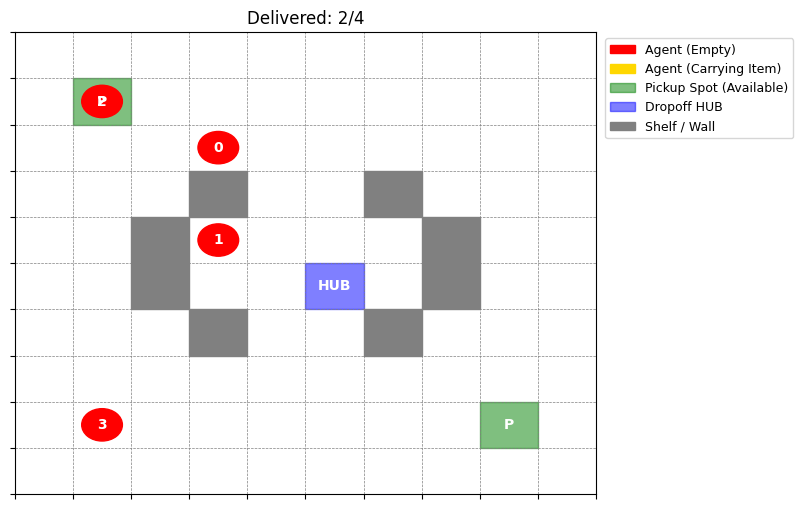

Evaluation Finished. Total Reward: 5.30


In [40]:
def evaluate_ddqn_warehouse(env, agent, max_steps=200):
    print("Running DDQN Evaluation...")
    observations = env.reset()
    norm_observations = [normalize_state(obs) for obs in observations]
    done = False
    step = 0
    total_reward = 0
    counter = 0
    
    try:
        while not done and step < max_steps:
            if counter % 10 == 0:
                env.render()

            action_indices = []
            
            for i in range(env.NUM_AGENTS):
                action = agent.get_action(norm_observations[i], epsilon=0)
                action_indices.append(action)
            
            action_strings = [env.action_space[index] for index in action_indices]
            next_obs, rewards, dones, _ = env.step(action_strings)
            norm_observations = [normalize_state(obs) for obs in next_obs]
            total_reward += sum(rewards)
            
            if all(dones):
                env.render()
                print(f"Success! Delivered in {step} steps.")
                done = True
            step += 1
            counter += 1
            time.sleep(0.2)

    except KeyboardInterrupt:
        print("Visualization stopped by user")

    print(f"Evaluation Finished. Total Reward: {total_reward:.2f}")

evaluate_ddqn_warehouse(env, warehouse_agent)

Starting Simple Tag Training (DDQN)...
Episode 0, Reward: 55.96
Episode 100, Reward: -3.22
Episode 200, Reward: -63.23
Episode 300, Reward: -223.78
Episode 400, Reward: 14.50
Episode 500, Reward: 0.00
Episode 600, Reward: 0.00
Episode 700, Reward: 23.41
Episode 800, Reward: 119.39
Episode 900, Reward: 0.00
Episode 1000, Reward: -4.04
Episode 1100, Reward: 0.00
Episode 1200, Reward: 40.00
Episode 1300, Reward: 0.00
Episode 1400, Reward: 99.24
Episode 1500, Reward: 50.21
Episode 1600, Reward: 40.00
Episode 1700, Reward: 40.00
Episode 1800, Reward: 0.00
Episode 1900, Reward: 34.06
Episode 2000, Reward: -0.02
Episode 2100, Reward: 100.00
Episode 2200, Reward: 13.44
Episode 2300, Reward: 56.15
Episode 2400, Reward: 59.63
Episode 2500, Reward: 39.48
Episode 2600, Reward: 40.00
Episode 2700, Reward: 0.00
Episode 2800, Reward: 48.19
Episode 2900, Reward: 112.30
Simple Tag Training Complete.


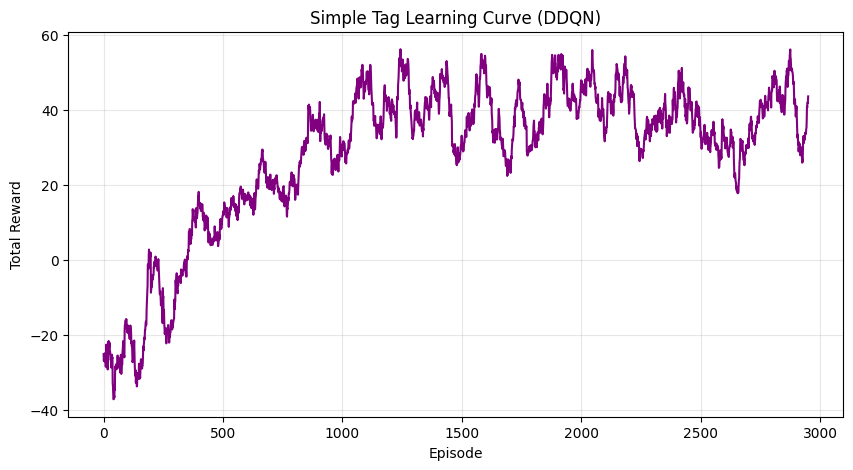

In [32]:
env_tag = simple_tag_v3.parallel_env(num_good=1, num_adversaries=3, num_obstacles=2, max_cycles=50, render_mode="rgb_array")
env_tag.reset()

adv_dim = env_tag.observation_space("adversary_0").shape[0]
good_dim = env_tag.observation_space("agent_0").shape[0]
adv_act = env_tag.action_space("adversary_0").n
good_act = env_tag.action_space("agent_0").n

adversary_agent = DDQNAgent(adv_dim, adv_act)
good_agent = DDQNAgent(good_dim, good_act)

print("Starting Simple Tag Training (DDQN)...")

tag_episodes = 3000
tag_rewards = []
epsilon = 1.0

for episode in range(tag_episodes):
    observations, infos = env_tag.reset()
    total_reward = 0
    
    while env_tag.agents:
        actions = {}
        agents_this_step = env_tag.agents[:] 
        
        for agent_id in agents_this_step:
            obs = observations[agent_id]
            if "adversary" in agent_id:
                act = adversary_agent.get_action(obs, epsilon)
            else:
                act = good_agent.get_action(obs, epsilon)
            actions[agent_id] = act
            
        next_observations, rewards, terminations, truncations, infos = env_tag.step(actions)
        
        for agent_id in agents_this_step:
            is_done = terminations.get(agent_id, False) or truncations.get(agent_id, False)
            r = rewards.get(agent_id, 0)
            
            if agent_id not in observations: 
                continue

            if "adversary" in agent_id:
                adversary_agent.buffer.push(
                    observations[agent_id], actions[agent_id], r, 
                    next_observations.get(agent_id, np.zeros(adv_dim)), is_done
                )
                adversary_agent.train_step(BATCH_SIZE, GAMMA)
            else:
                good_agent.buffer.push(
                    observations[agent_id], actions[agent_id], r, 
                    next_observations.get(agent_id, np.zeros(good_dim)), is_done
                )
                good_agent.train_step(BATCH_SIZE, GAMMA)
                
            total_reward += r
            
        observations = next_observations

        if not env_tag.agents: 
            break

    epsilon = max(0.05, epsilon * 0.9995)
    tag_rewards.append(total_reward)
    
    if episode % 100 == 0:
        adversary_agent.update_target_net()
        good_agent.update_target_net()
        print(f"Episode {episode}, Reward: {total_reward:.2f}")

print("Simple Tag Training Complete.")

plt.figure(figsize=(10, 5))
plt.plot(np.convolve(tag_rewards, np.ones(50)/50, mode="valid"), color="purple")
plt.title("Simple Tag Learning Curve (DDQN)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True, alpha=0.3)
plt.show()

In [37]:
print("Evaluating Simple Tag and Generating GIF...")
fig, ax = plt.subplots(figsize=(6, 6))
frames = []
observations, infos = env_tag.reset()

while env_tag.agents:
    frame = env_tag.render() 
    frames.append([ax.imshow(frame)])
    actions = {}
    
    for agent_id in env_tag.agents:
        obs = observations[agent_id]

        if "adversary" in agent_id:
            action = adversary_agent.get_action(obs, epsilon=0)

        else:
            action = good_agent.get_action(obs, epsilon=0)

        actions[agent_id] = action
    
    observations, _, _, _, _ = env_tag.step(actions)

ax.axis("off")
ani = animation.ArtistAnimation(fig, frames, interval=100, blit=True, repeat_delay=1000)
ani.save("simple_tag_ddqn.gif", writer="pillow")
plt.close()

print("GIF saved as 'simple_tag_ddqn.gif'!")

Evaluating Simple Tag and Generating GIF...
GIF saved as 'simple_tag_ddqn.gif'!
